In [ ]:
#Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

#Do more restaurants provide online delivery compared to offline services?
#Which types of restaurants are most favored by the general public?
#What price range do couples prefer for dining out?



In [1]:
import pandas as pd #Pandas is one of the most used libraries in Python for data science or data analysis. It can read data from CSV or Excel files, manipulate the data, and generate insights from it. Pandas can also be used to clean data, filter data, and visualize data.
import numpy as np #Numpy is a general-purpose array-processing package. It provides a high-performance multidimensional array object and tools for working with these arrays. It is the fundamental package for scientific computing with Python
import matplotlib.pyplot as plt #Matplotlib is a Python library used for creating static, animated and interactive data visualizations. It is built on the top of NumPy and it can easily handles large datasets for creating various types of plots such as line charts, bar charts, scatter plots, etc.
import seaborn as sns #Seaborn is a Python data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. This article deals with the distribution plots in seaborn which is used for examining univariate and bivariate distributions.

In [2]:
#Creating th data frame

dataframe = pd.read_csv("Zomato-data-.csv") #read the data set
print(dataframe.head())  #retrive the first 5 rows of the dataset.

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [3]:
# Data Cleaning and Preparation
# Convert the rate column to a float by removing denominator characters.
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())  

#rate coulmn 4.1/5 not numeric so we can't analyze this directly.
# so we first turn whole thing to a string. 
#then split 2 values (4.1,5).
#Then keep only the numerator part under column rate.

# this method only can be use if we have dataset with no values like 'NEW','-','NAN'

#Below we can see the edited data row


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [4]:
# getting the summary of data
dataframe.info()

#7 columns,148 entries,all columns have same number of entries so no non null values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [5]:
# Checking for missing or null values to identify any data gaps.
print(dataframe.isnull().sum())

#so no non null values or missing values.

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


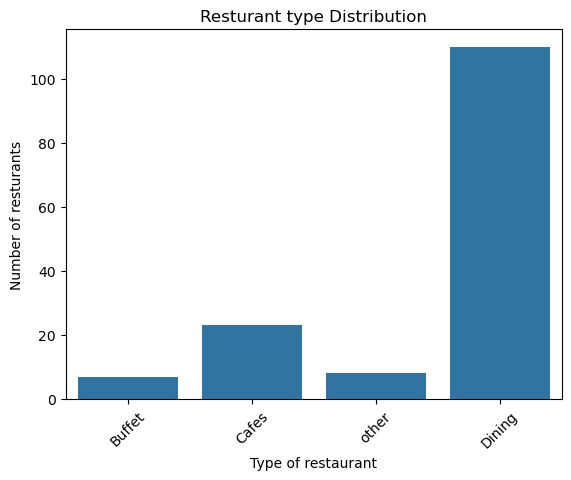

In [23]:
#Exploring Restaurant Types
#craete bar chart of resturant types to see popular resturant categories.
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")
plt.ylabel("Number of resturants")
plt.title("Resturant type Distribution")
plt.xticks(rotation=45)
plt.show() # to remove output of plt.sticks use this

# So according to the data distribution we can conclude that Dining base resturant type is the most distributed resturant type.

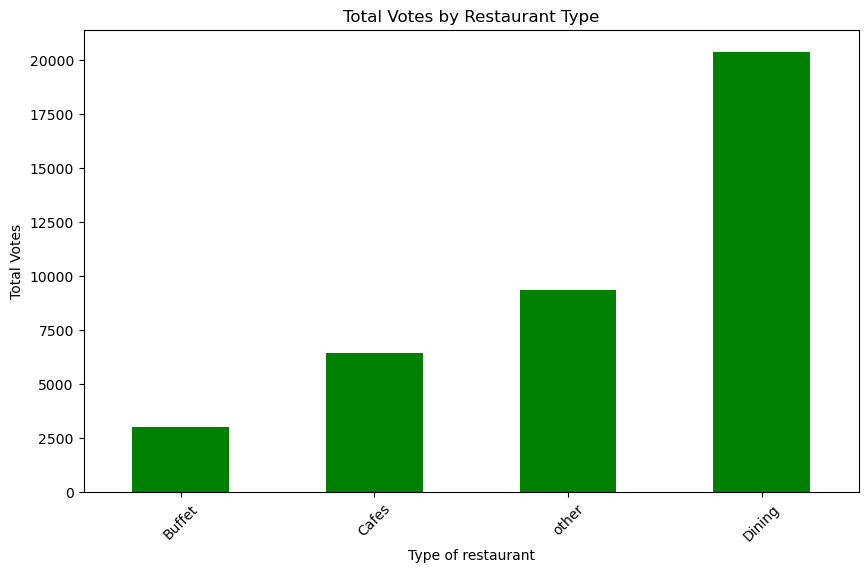

In [28]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum().sort_values()# Groups data by restaurant type,Sums total votes for each type


plt.figure(figsize=(10,6)) #Make chart wider (10),Make chart taller (6)


grouped_data.plot(kind='bar', color='green')

plt.xlabel('Type of restaurant')
plt.ylabel('Total Votes')
plt.title('Total Votes by Restaurant Type')
plt.xticks(rotation=45)

plt.show()

#Insights
#“Dining restaurants receive the highest number of votes, indicating higher customer engagement.”
#“Buffet-type restaurants have comparatively lower interaction.”

In [32]:
#Identify the Most Voted Restaurant
max_votes = dataframe['votes'].max()

top_restaurants = dataframe[dataframe['votes'] == max_votes][['name', 'votes']]

print(top_restaurants)

                 name  votes
38  Empire Restaurant   4884


In [33]:
#Top 5 restaurants
top5 = dataframe.sort_values(by='votes', ascending=False)[['name', 'votes']].head()

print(top5)

                 name  votes
38  Empire Restaurant   4884
86      Meghana Foods   4401
7              Onesta   2556
44             Onesta   2556
65        Kabab Magic   1720


In [34]:
#Finding the highest rated resturant.
max_rating = dataframe['rate'].max()

top_rated = dataframe[dataframe['rate'] == max_rating][['name', 'rate']]

print("Highest Rated Restaurant(s):")
print(top_rated)

Highest Rated Restaurant(s):
      name  rate
7   Onesta   4.6
44  Onesta   4.6


Text(0, 0.5, 'Count')

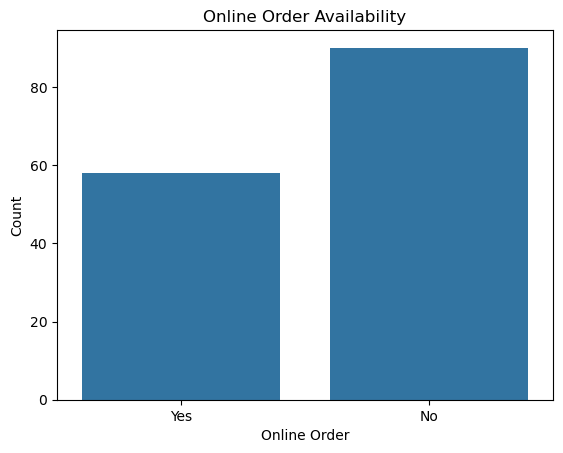

In [37]:
#Finding the online order availability.
sns.countplot(x='online_order', data=dataframe)
plt.title("Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Count")


In [ ]:
#Insights
#Majority of resturants don't accept online orders.


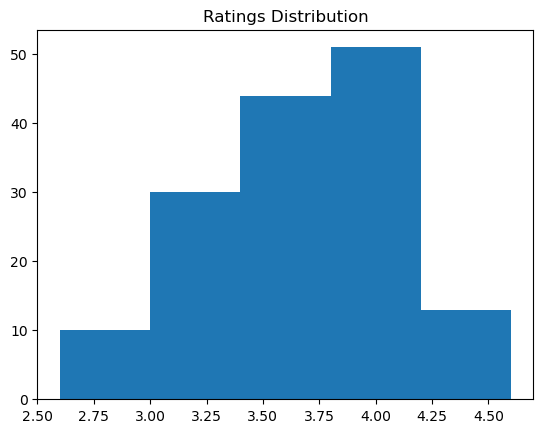

In [40]:
#Checking the distribution of ratings from the rate column.
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

#most rartings distrbuting between 3.5-4

<AxesSubplot: xlabel='approx_cost(for two people)', ylabel='count'>

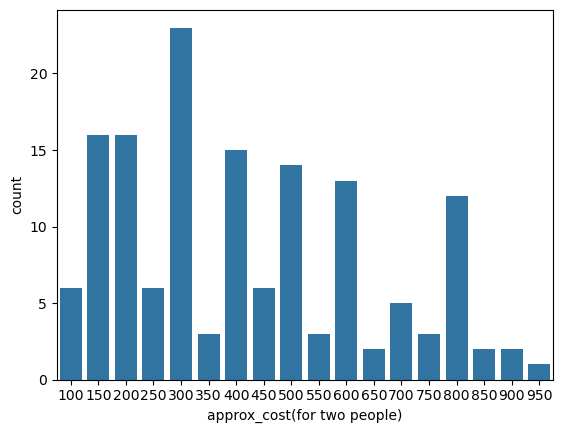

In [43]:
#Analyze the approx_cost(for two people) column to find the preferred price range.
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

#Most plot on approximatly 300.
#Most restaurants cost between ₹300–₹800
#Very expensive restaurants are fewer
#Distribution may be right-skewed (more low-cost options)

<AxesSubplot: xlabel='online_order', ylabel='rate'>

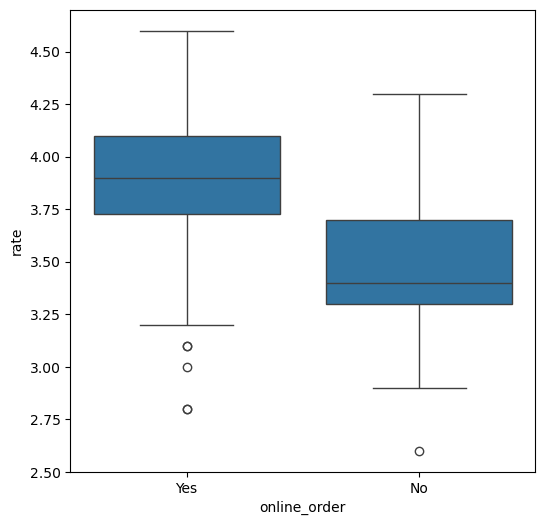

In [45]:
#Compare ratings between restaurants that accept online orders and those that don't.
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

#insights
#“Restaurants offering online ordering tend to have slightly higher median ratings.”
#“Non-online-order restaurants show more variability in ratings.”
#“Outliers exist in both categories, indicating exceptional cases.”

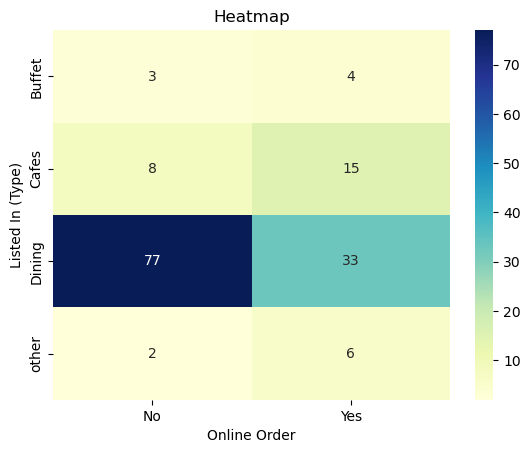

In [47]:
#Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

#Insights 
#“Dining restaurants show a strong preference for online ordering.”
#“Buffet-type restaurants are less likely to offer online ordering.”
#“Cafes maintain a balanced distribution between online and offline services.”

In [50]:
#Top resturants keeping high ratings and engagements.

top_restaurants = dataframe[dataframe['votes'] > 100] \
    .sort_values(by='rate', ascending=False)[['name','rate','votes']] \
    .head(10)

print(top_restaurants)

                      name  rate  votes
44                  Onesta   4.6   2556
7                   Onesta   4.6   2556
38       Empire Restaurant   4.4   4884
86           Meghana Foods   4.4   4401
52  Corner House Ice Cream   4.3    345
60           Peppy Peppers   4.2    244
81           Frozen Bottle   4.2    146
37         Szechuan Dragon   4.2   1647
9                Smacznego   4.2    504
34                  Faasos   4.2    415


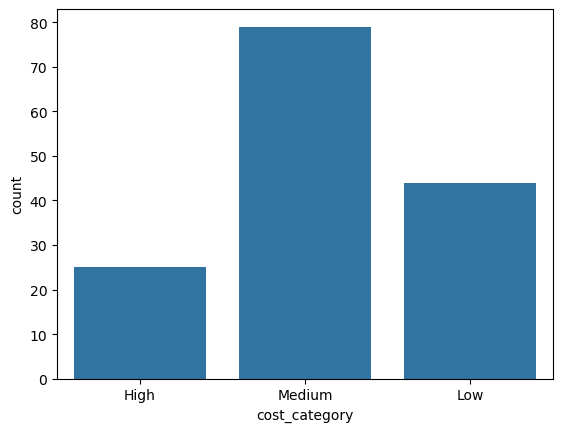

In [53]:
#Price Segmentation

def categorize_cost(x):
    if x < 300:
        return 'Low'
    elif x < 700:
        return 'Medium'
    else:
        return 'High'

dataframe['cost_category'] = dataframe['approx_cost(for two people)'].apply(categorize_cost)

sns.countplot(x='cost_category', data=dataframe)
plt.show()

<AxesSubplot: xlabel='votes', ylabel='rate'>

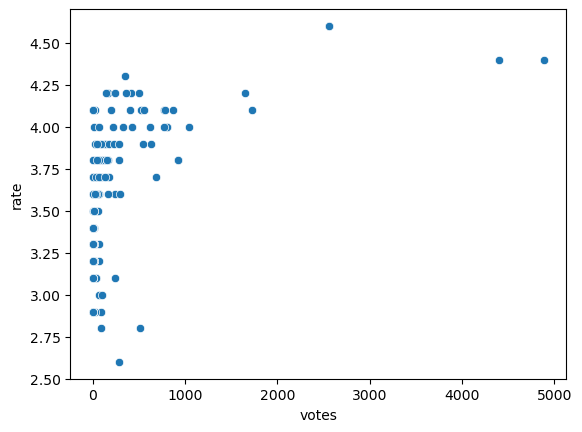

In [54]:
#Examine whether popular resturants has good ratings
sns.scatterplot(x='votes', y='rate', data=dataframe)



In [ ]:
#Key Insights of Hall Project
# 1.Most restaurants fall in the mid-price range
# 2.Dining restaurants receive the highest votes
# 3 .Restaurants with online ordering tend to have better ratings
# 4.Ratings are mostly between 3.5 – 4.5
# 5.Some outliers exist (extremely high/low ratings)

In [56]:
dataframe.to_csv('restaurants_cleaned.csv', index=False)